In [ ]:
%pip install tsfeatures

In [18]:
# MCC - Temas Selectos III 
# Instructor: Dr. J.A. Garcia-Rodriguez
# FEATURES OF TIME SERIES DATA


import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [19]:
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#D55F03", "#569CC6", "#13A076", "#CC79A7"])

In [ ]:
# In a cmd terminal you can inspect the file to look at what are the columns by
# "type file_name.csv" 
# In a PowerShell terminal you can inspect the file to look at what are the columns by
# "Get-Content file_name.csv -First 10"

In [ ]:
# Help: DataFrame.nunique(axis=0, dropna=True)
# Count number of distinct elements in specified axis.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html

aus_tourism = pd.read_csv("06_tourism.csv", parse_dates=["ds"])
aus_tourism["unique_id"].nunique()

In [ ]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df

In [ ]:
mean_df.sort_values(by="y").head(10)

In [ ]:
# Help: https://pypi.org/project/tsfeatures/
# tsfeatures: Calculates various features from time series data. 

summary_stats = tsf.tsfeatures(aus_tourism,
                               freq=4, 
                               features=[tsf.statistics], 
                               scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(20)

### **Electricty Demand Problem**
Dataset contains half-hourly (freq="30min") electricity demand for the state of Victoria, Australia. It can be plotted the daily pattern, weekly pattern or yearly pattern by grouping according to date, week and year

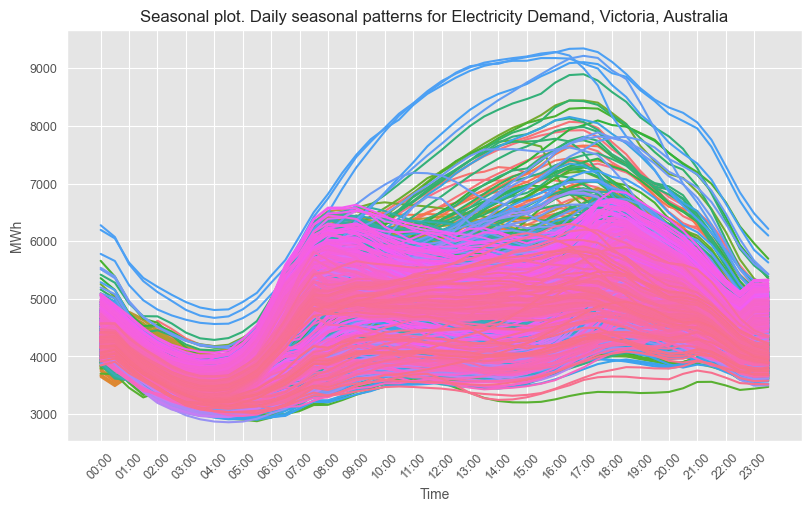

In [20]:
elec_df = pd.read_csv("07_elec.csv", parse_dates=["ds"])
elec_demand = elec_df[elec_df["unique_id"] == "Demand"]
df = elec_demand.assign(
    hour_minute=lambda x: x["ds"].dt.strftime("%H:%M"),
    day=lambda x: x["ds"].dt.date,
)

fig, ax = plt.subplots()
sns.lineplot(data=df, x="hour_minute", y="y",
    hue="day", palette="husl", legend=False, ax=ax)
ax.set(
    title="Seasonal plot. Daily seasonal patterns for Electricity Demand, Victoria, Australia",
    xlabel="Time",
    ylabel="MWh",
)
unique_ticks = df["hour_minute"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()

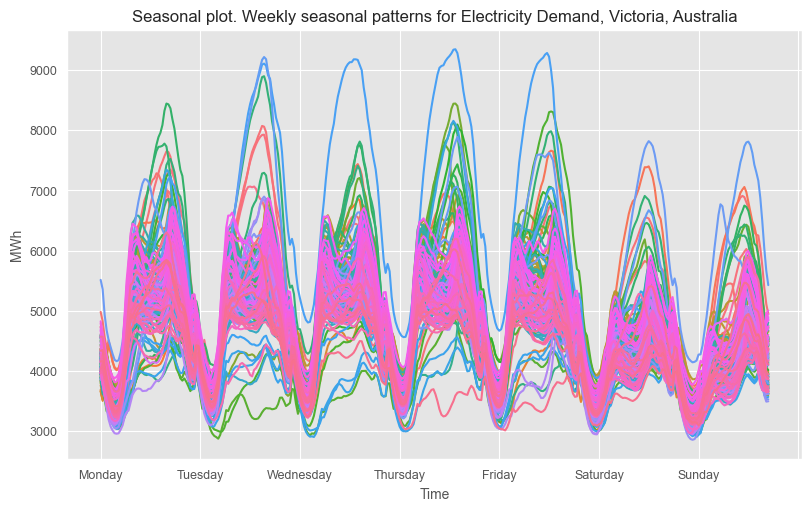

In [21]:
df = (elec_demand
      .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
      .assign(day_of_week=lambda x: x["ds"].dt.day_name(),
              week=lambda x: x["ds"].dt.to_period("W").dt.start_time,)
              )
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots()
for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",
        ax=ax, color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Seasonal plot. Weekly seasonal patterns for Electricity Demand, Victoria, Australia",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

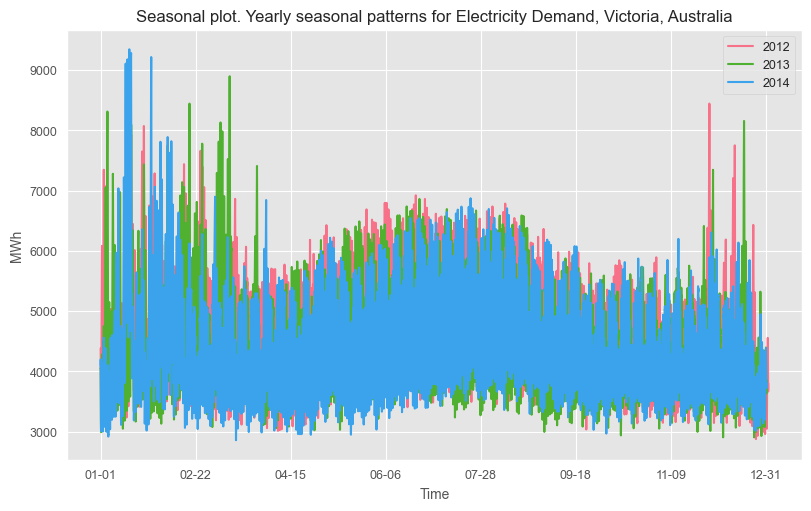

In [22]:
df = elec_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)

palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots()
for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax,
        label=str(year), color=palette[i_year])
ax.set(
    title="Seasonal plot. Yearly seasonal patterns for Electricity Demand, Victoria, Australia",
    ylabel="MWh",
    xlabel="Time",
)
fig.show()

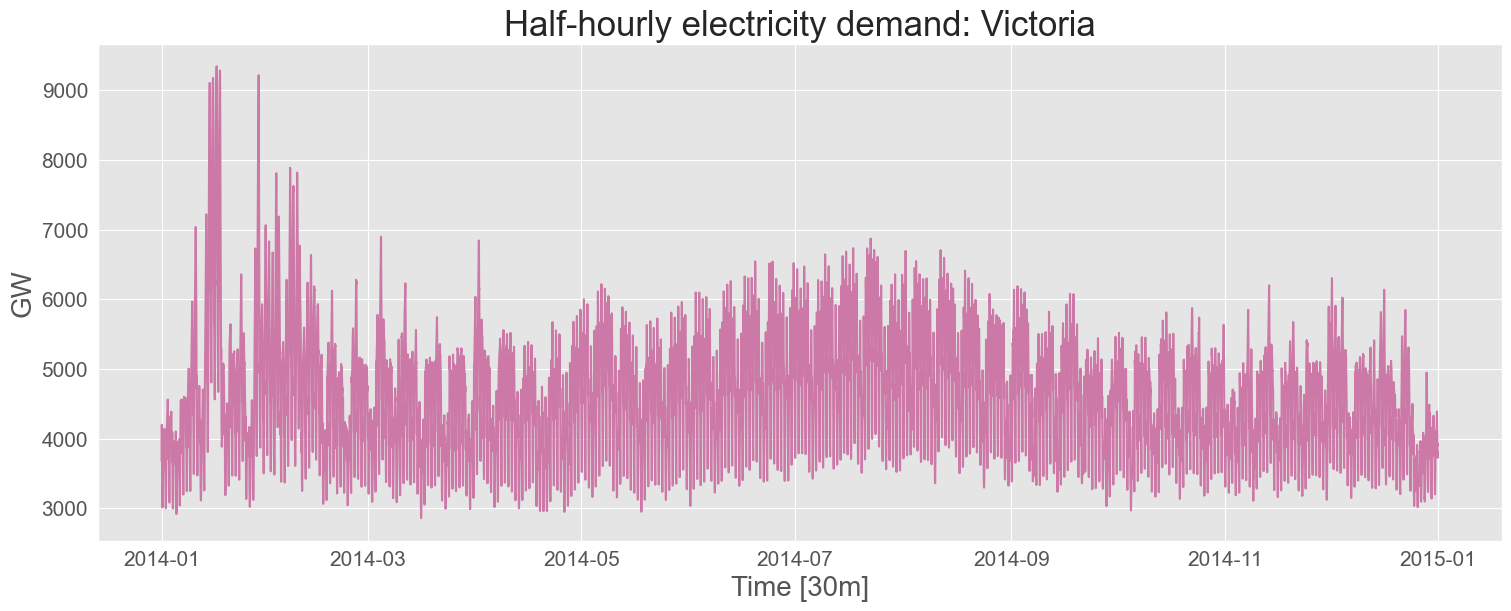

In [23]:
plot_series(elec_df, ids=["Demand"],
    max_insample_length=2 * 24 * 365,
    xlabel="Time [30m]", ylabel="GW",
    title="Half-hourly electricity demand: Victoria")

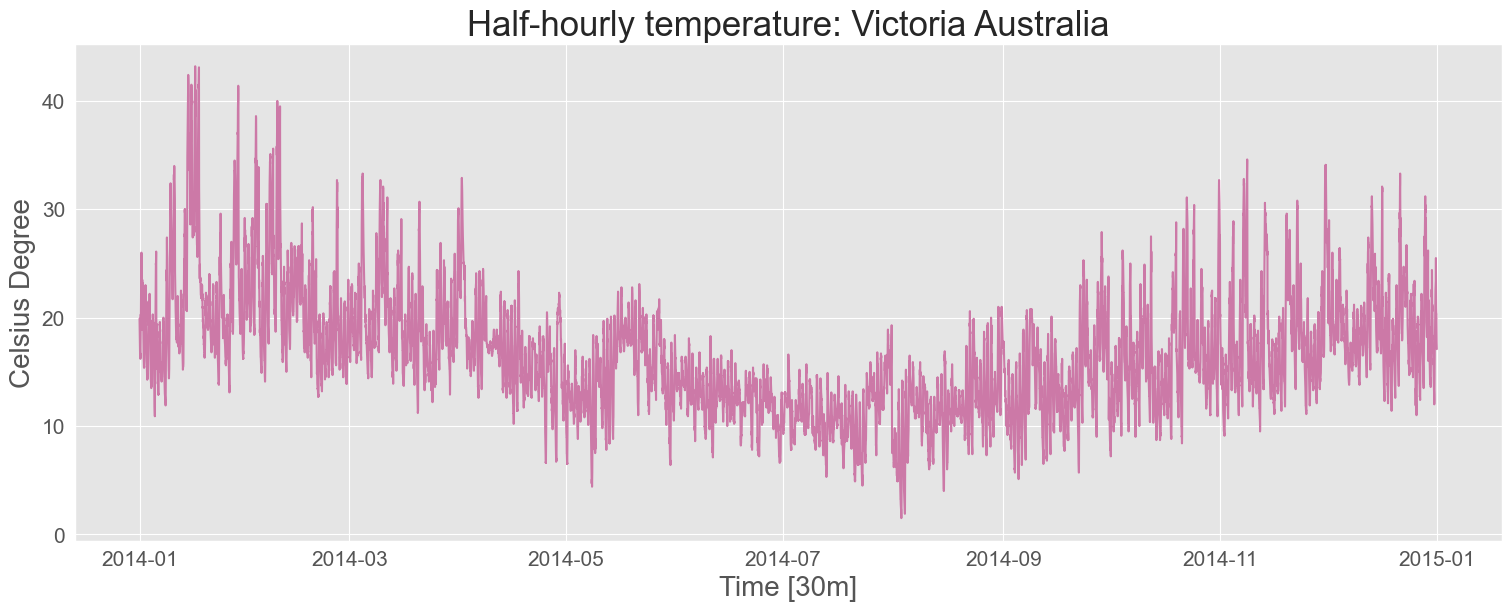

In [ ]:
plot_series(elec_df, ids=["Temperature"],
    max_insample_length=2 * 24 * 365,
    xlabel="Time [30m]", ylabel="Celsius Degrees",
    title="Half-hourly temperature: Victoria Australia")

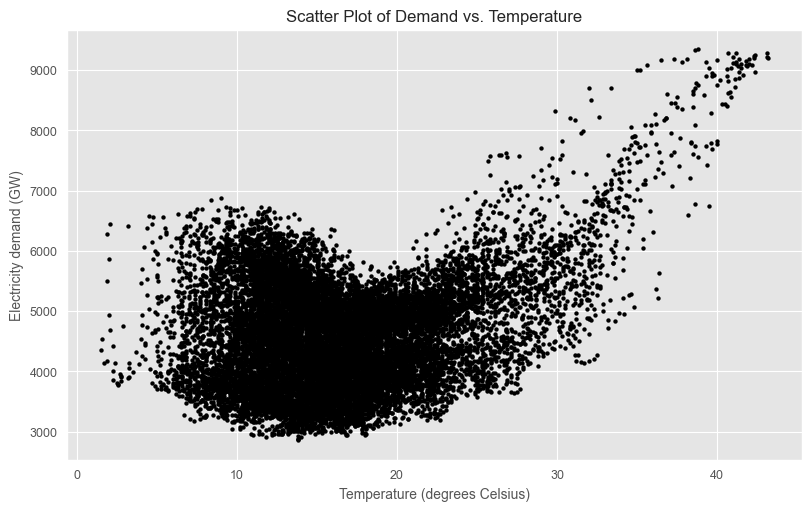

In [27]:
elec_2014 = (elec_df.loc[lambda x: x["ds"].dt.year == 2014]
             .pivot(index="ds", columns="unique_id", values="y")
             .reset_index()
             )

fig, ax = plt.subplots()
sns.scatterplot(data=elec_2014, x="Temperature", y="Demand",
                ax=ax, linewidth=0, s=10, color="k", legend=False)

ax.set(
    title="Scatter Plot of Demand vs. Temperature",
    xlabel="Temperature (degrees Celsius)",
    ylabel="Electricity demand (GW)",
    )

fig.show()

### **Lag plots**

In [ ]:
# In a cmd terminal you can inspect the file to look at what are the columns by
# type 08_aus_production.csv 
# In a PowerShell terminal you can inspect the file to look at what are the columns by
# Get-Content 08_aus_production.csv -First 10

In [28]:
beer = (pd.read_csv("08_aus_production.csv", parse_dates=["ds"], date_format='%d/%m/%Y'))
beer

,ds,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956-01-01,284,5225.0,189.0,465,3923,5
1,1956-04-01,213,5178.0,204.0,532,4436,6
2,1956-07-01,227,5297.0,208.0,561,4806,7
3,1956-10-01,308,5681.0,197.0,570,4418,6
4,1957-01-01,262,5577.0,187.0,529,4339,5
...,...,...,...,...,...,...,...
213,2009-04-01,398,NaN,NaN,2160,57471,238
214,2009-07-01,419,NaN,NaN,2325,58394,252
215,2009-10-01,488,NaN,NaN,2273,57336,210
216,2010-01-01,414,NaN,NaN,1904,58309,205


In [29]:
beer = beer[["ds", "Beer"]].loc[beer["ds"] >= "2000"]
beer

,ds,Beer
176,2000-01-01,421
177,2000-04-01,402
178,2000-07-01,414
179,2000-10-01,500
180,2001-01-01,451
181,2001-04-01,380
182,2001-07-01,416
183,2001-10-01,492
184,2002-01-01,428
185,2002-04-01,408


In [30]:
beer["Season"] = ("Q" + beer["ds"].dt.quarter.astype("string"))
beer = beer.rename(columns={"Beer": "y"})
beer

,ds,y,Season
176,2000-01-01,421,Q1
177,2000-04-01,402,Q2
178,2000-07-01,414,Q3
179,2000-10-01,500,Q4
180,2001-01-01,451,Q1
181,2001-04-01,380,Q2
182,2001-07-01,416,Q3
183,2001-10-01,492,Q4
184,2002-01-01,428,Q1
185,2002-04-01,408,Q2


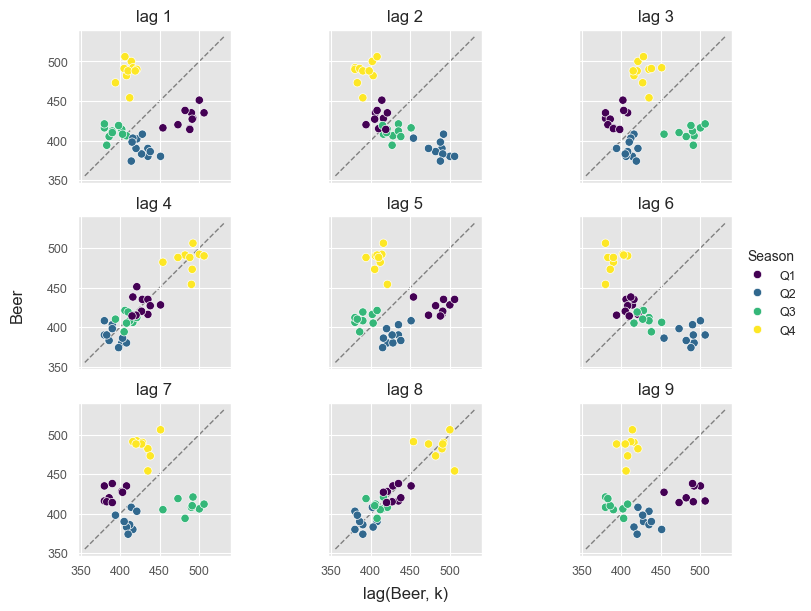

In [31]:
lims = 0.95 * beer["y"].min(), 1.05 * beer["y"].max()
cmap = plt.get_cmap("viridis")

colors = {season: cmap(i / 3)
          for i, season in enumerate(beer["Season"].unique())
          }

fig, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    df = beer.assign(lag=beer["y"].shift(lag))
    sns.scatterplot(data=df, x="lag", y="y", hue="Season",
        palette=colors, ax=ax)
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag}", xlabel="", ylabel="", aspect="equal")
    ax.get_legend().remove()
axes[1, -1].legend(loc="center left", title="Season",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.supxlabel("lag(Beer, k)")
fig.supylabel("Beer")
fig.show()


In [32]:
df = beer.sort_values("ds").copy()
df

,ds,y,Season
176,2000-01-01,421,Q1
177,2000-04-01,402,Q2
178,2000-07-01,414,Q3
179,2000-10-01,500,Q4
180,2001-01-01,451,Q1
181,2001-04-01,380,Q2
182,2001-07-01,416,Q3
183,2001-10-01,492,Q4
184,2002-01-01,428,Q1
185,2002-04-01,408,Q2


In [33]:
df["lag_1"] = df["y"].shift(1)
df

,ds,y,Season,lag_1
176,2000-01-01,421,Q1,NaN
177,2000-04-01,402,Q2,421.0
178,2000-07-01,414,Q3,402.0
179,2000-10-01,500,Q4,414.0
180,2001-01-01,451,Q1,500.0
181,2001-04-01,380,Q2,451.0
182,2001-07-01,416,Q3,380.0
183,2001-10-01,492,Q4,416.0
184,2002-01-01,428,Q1,492.0
185,2002-04-01,408,Q2,428.0


In [34]:
df = df.dropna(subset=["lag_1"])
df

,ds,y,Season,lag_1
177,2000-04-01,402,Q2,421.0
178,2000-07-01,414,Q3,402.0
179,2000-10-01,500,Q4,414.0
180,2001-01-01,451,Q1,500.0
181,2001-04-01,380,Q2,451.0
182,2001-07-01,416,Q3,380.0
183,2001-10-01,492,Q4,416.0
184,2002-01-01,428,Q1,492.0
185,2002-04-01,408,Q2,428.0
186,2002-07-01,406,Q3,408.0


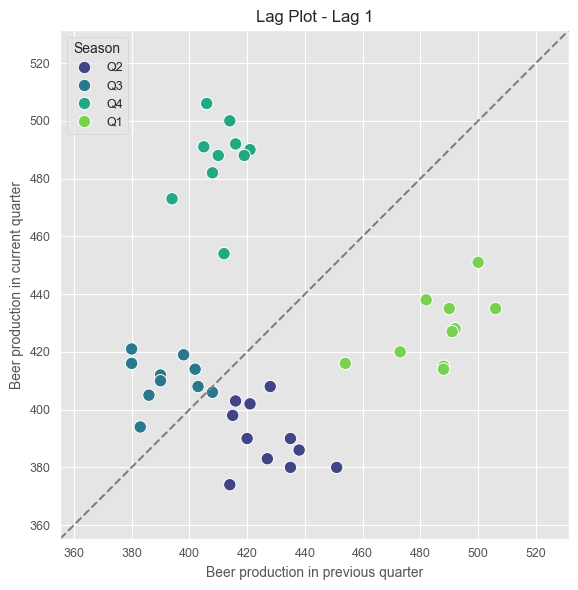

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=df,
    x="lag_1",
    y="y",
    hue="Season",
    palette="viridis",
    ax=ax,
    s=80
)

lims = (
    0.95 * beer["y"].min(),
    1.05 * beer["y"].max()
)

ax.plot(lims, lims, "--", color="gray")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Beer production in previous quarter")
ax.set_ylabel("Beer production in current quarter")
ax.set_title("Lag Plot - Lag 1")
plt.tight_layout()
plt.show()